📈 Notebook 02: Sales & Time Trends Analysis

Questo notebook si concentra sull'analisi temporale e sull'andamento delle vendite nel tempo:

Analisi dell'andamento mensile e annuale dei ricavi.

Identificazione della stagionalità dei prodotti (es. picchi in Q4).

Calcolo della crescita Anno su Anno (YoY Growth) e Mese su Mese (MoM Growth).

Analisi delle performance dei tempi di spedizione.

### 1. Importazione Librerie e Caricamento Dati Puliti

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione stile grafici
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Caricamento del dataset pulito nel notebook precedente
CLEANED_DATA_PATH = '../data/superstore_cleaned.csv'
df = pd.read_csv(CLEANED_DATA_PATH)

# Assicuriamoci che i campi data siano riconosciuti come datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(f"Dataset caricato correttamente: {len(df)} righe.")

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row ID               9800 non-null   int64         
 1   Order ID             9800 non-null   str           
 2   Order Date           9800 non-null   datetime64[us]
 3   Ship Date            9800 non-null   datetime64[us]
 4   Ship Mode            9800 non-null   str           
 5   Customer ID          9800 non-null   str           
 6   Customer Name        9800 non-null   str           
 7   Segment              9800 non-null   str           
 8   Country              9800 non-null   str           
 9   City                 9800 non-null   str           
 10  State                9800 non-null   str           
 11  Postal Code          9800 non-null   int64         
 12  Region               9800 non-null   str           
 13  Product ID           9800 non-null   str    

### 2. Andamento delle Vendite per Anno e Mese

,Anno,Vendite Totali,Numero Ordini,Valore Medio Ordine
0,2015,479856.2081,1953,245.702103
1,2016,459436.0054,2055,223.569832
2,2017,600192.5500,2534,236.855781
3,2018,722052.0192,3258,221.624315


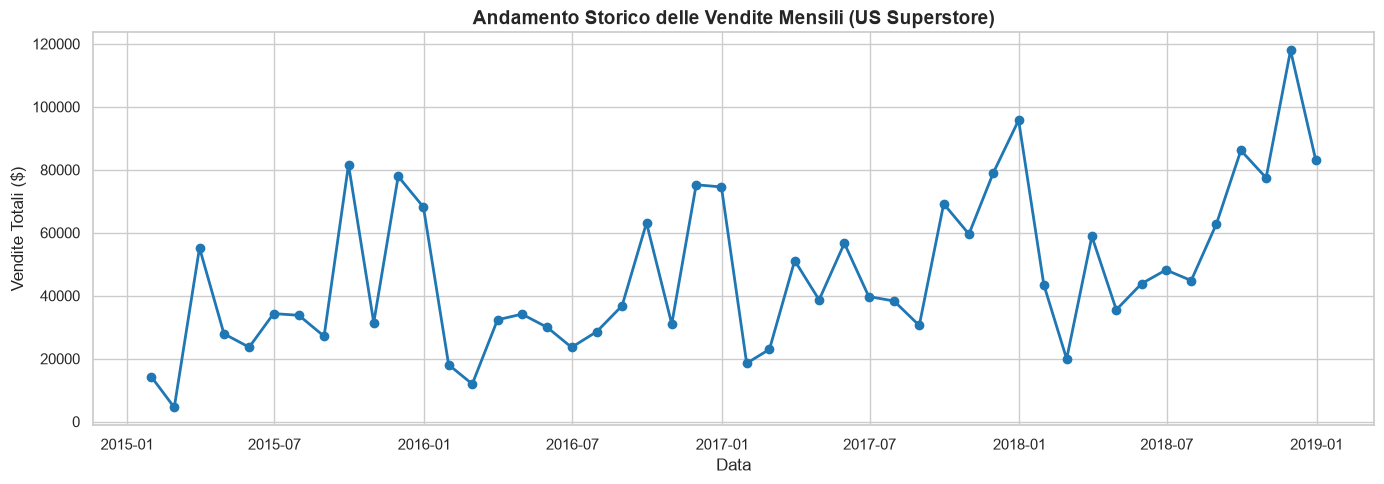

In [6]:
# Aggregate per Anno
yearly_sales = df.groupby('Order Year')['Sales'].agg(['sum', 'count', 'mean']).reset_index()
yearly_sales.columns = ['Anno', 'Vendite Totali', 'Numero Ordini', 'Valore Medio Ordine']
display(yearly_sales)

# Resampling mensile continuo per valutare il trend storico
monthly_trend = df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()

# Grafico delle vendite mensili nel tempo
plt.figure(figsize=(14, 5))
plt.plot(monthly_trend['Order Date'], monthly_trend['Sales'], marker='o', color='#1f77b4', linewidth=2)
plt.title("Andamento Storico delle Vendite Mensili (US Superstore)", fontsize=14, fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendite Totali ($)")
plt.tight_layout()
plt.show()

### 3. Analisi della Stagionalità (Seasonality Analysis)

Order Year,2015,2016,2017,2018
Order Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


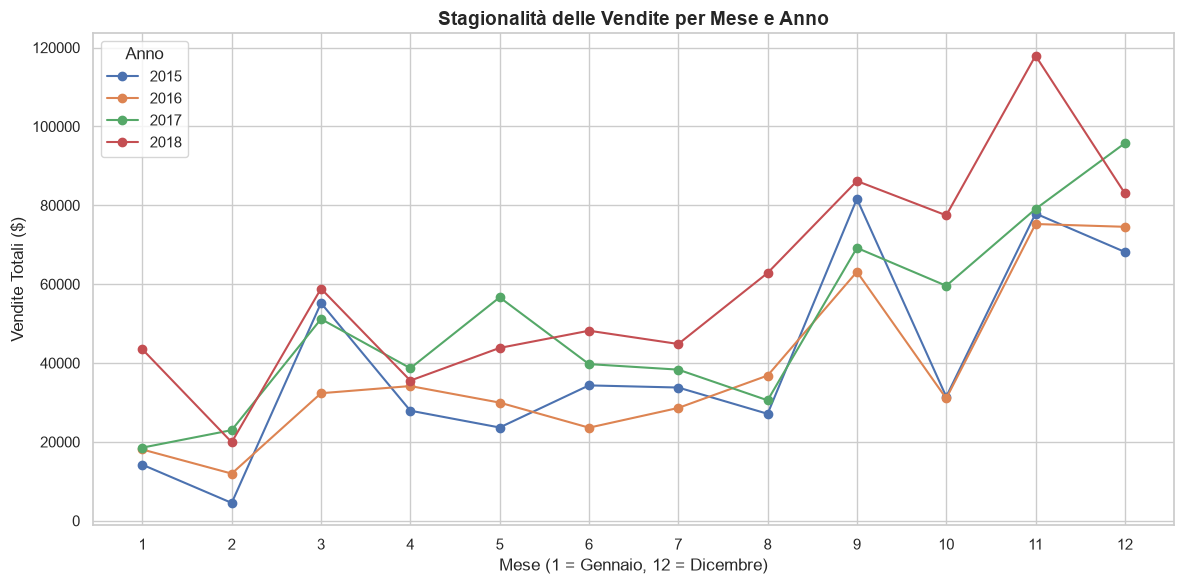

In [7]:
# Pivot Table: Anno sulle colonne, Mese sulle righe per confrontare i comportamenti annuali
monthly_pivot = df.pivot_table(index='Order Month', columns='Order Year', values='Sales', aggfunc='sum')

display(monthly_pivot)

# Visualizzazione della stagionalità
monthly_pivot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title("Stagionalità delle Vendite per Mese e Anno", fontsize=14, fontweight='bold')
plt.xlabel("Mese (1 = Gennaio, 12 = Dicembre)")
plt.ylabel("Vendite Totali ($)")
plt.xticks(range(1, 13))
plt.legend(title="Anno")
plt.tight_layout()
plt.show()

### 4. Calcolo Crescita Anno su Anno (YoY) e Mese su Mese (MoM)

In [10]:
# A. Crescita Anno su Anno (YoY)
yearly_sales['YoY_Growth_%'] = yearly_sales['Vendite Totali'].pct_change() * 100
print("--- CRESCITA ANNUALE (YoY) ---")
display(yearly_sales[['Anno', 'Vendite Totali', 'YoY_Growth_%']])

# B. Crescita Mese su Mese (MoM) nel trend continuo
monthly_trend['MoM_Growth_%'] = monthly_trend['Sales'].pct_change() * 100

print("\n--- ULTIMI 12 MESI CON CRESCITA MoM ---")
display(monthly_trend.tail(12))

--- CRESCITA ANNUALE (YoY) ---


,Anno,Vendite Totali,YoY_Growth_%
0,2015,479856.2081,NaN
1,2016,459436.0054,-4.255484
2,2017,600192.5500,30.636812
3,2018,722052.0192,20.303396



--- ULTIMI 12 MESI CON CRESCITA MoM ---


,Order Date,Sales,MoM_Growth_%
36,2018-01-31,43476.4740,-54.588601
37,2018-02-28,19920.9974,-54.179823
38,2018-03-31,58863.4128,195.484265
39,2018-04-30,35541.9101,-39.619692
40,2018-05-31,43825.9822,23.307898
41,2018-06-30,48190.7277,9.959265
42,2018-07-31,44825.1040,-6.983965
43,2018-08-31,62837.8480,40.184500
44,2018-09-30,86152.8880,37.103499
45,2018-10-31,77448.1312,-10.103848


### 5. Performance dei Tempi di Spedizione (Shipping Efficiency)

In [11]:
# Calcolo tempi medi di spedizione per Ship Mode
shipping_summary = (
    df.groupby('Ship Mode')['Shipping Days']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Giorni Medi', 'median': 'Mediana Giorni', 'count': 'Totale Spedizioni'})
)

shipping_summary['Giorni Medi'] = shipping_summary['Giorni Medi'].round(2)
display(shipping_summary)

,Ship Mode,Giorni Medi,Mediana Giorni,min,max,Totale Spedizioni
0,First Class,2.18,2.0,1,4,1501
1,Same Day,0.04,0.0,0,1,538
2,Second Class,3.25,3.0,1,5,1902
3,Standard Class,5.01,5.0,3,7,5859
